Generating synthetic data for testing...

--- Test 1: analyze_mask ---
Detected cells: 10
Areas:          [0.0118, 0.005, 0.0118]
Intensities:    [0.7864, 0.7877, 0.7922]

--- Test 2: collect_features ---
Real  — n=30, mean area=0.0108
Sim   — n=24,  mean area=0.0109

--- Test 3: collect_pixels ---
Real pixels — n=5293, mean=0.8001
Sim  pixels — n=4268,  mean=0.6154

--- Test 4: collect_cell_std ---
Real std — mean=0.0577
Sim  std — mean=0.1233

--- Test 5: fit_gmm + kl_gmm ---
KL(real || sim) = 89.13

--- Test 6: fit_gmm_1d + kl_gmm_1d ---
KL area (real || sim) = 0.77
KL intensity (real || sim) = 64.71

--- Test 7: collect_hog_features ---
Real HOG — shape=(6144,), mean=0.0717
Sim  HOG — shape=(6144,),  mean=0.0637

--- Test 8: collect_sift_descriptors ---
Real SIFT — n=13440, mean=26.2607
Sim  SIFT — n=13440,  mean=23.8678

--- Test 9: visualize_sift_keypoints ---


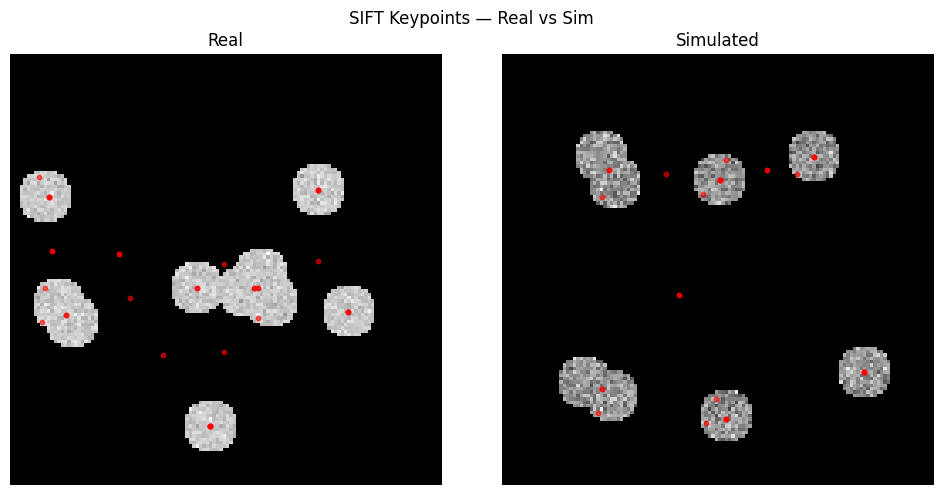

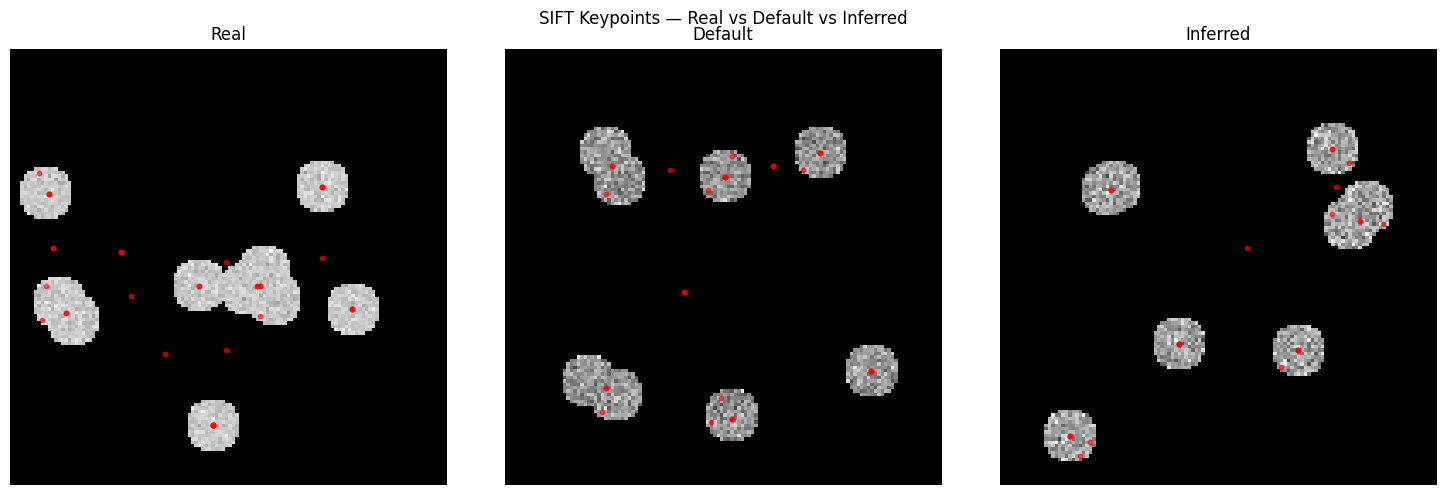


--- Test 10: plots ---


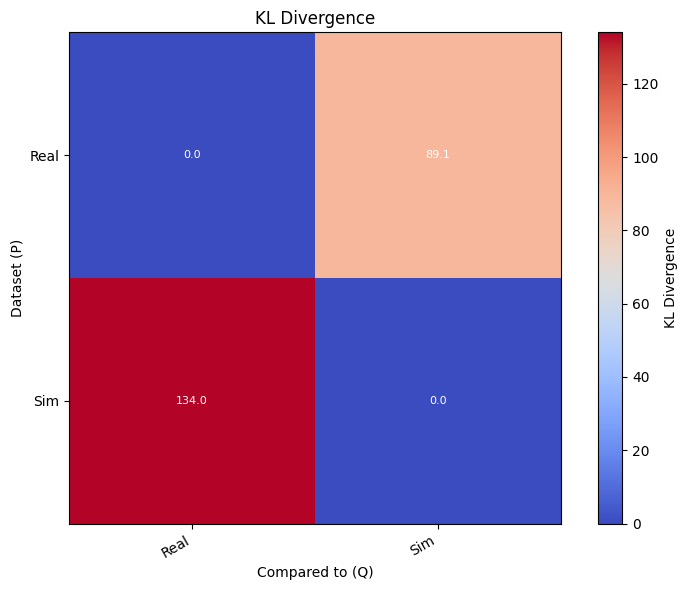

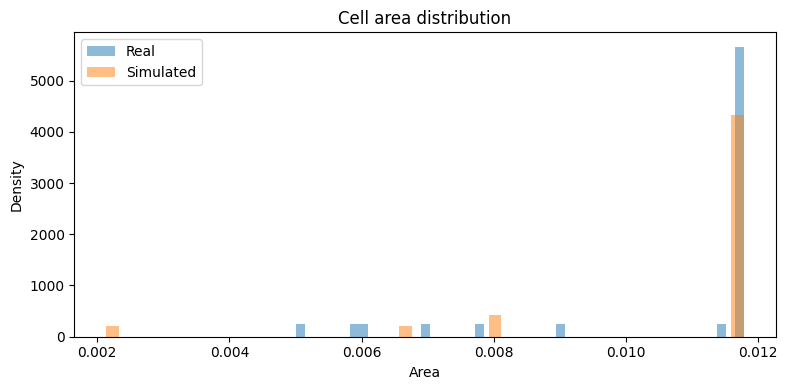

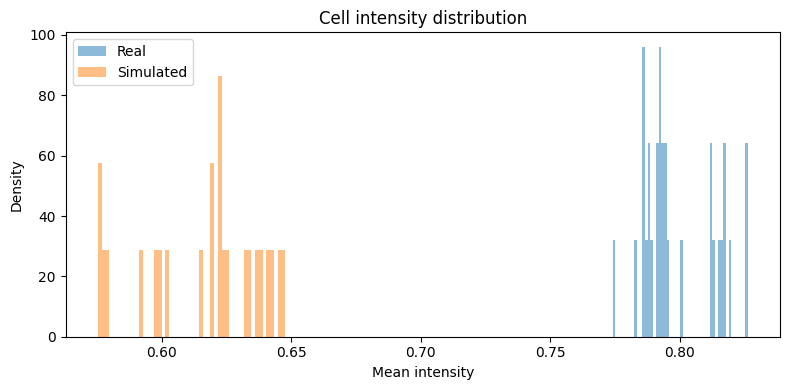

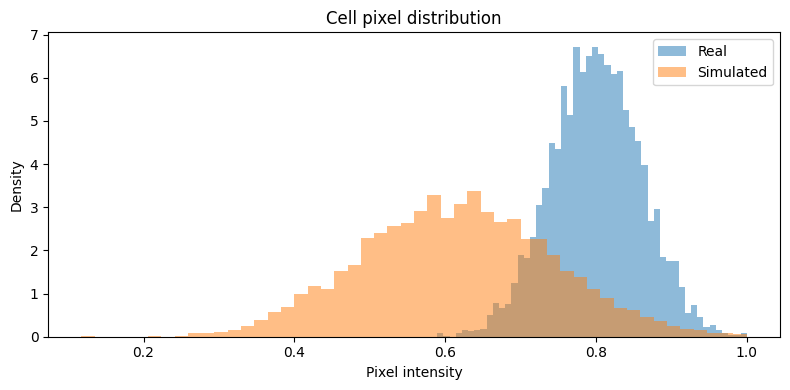

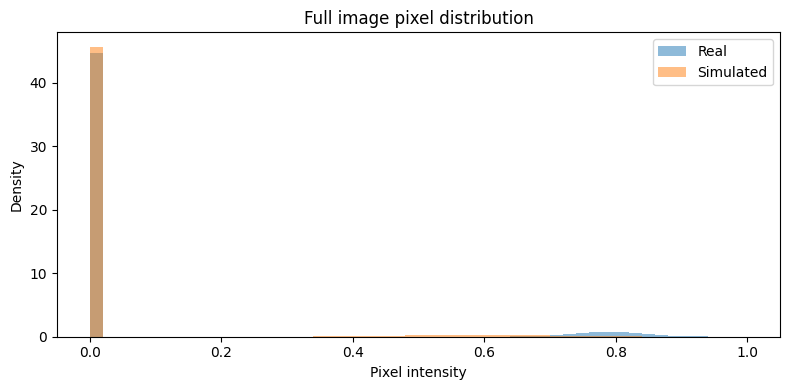

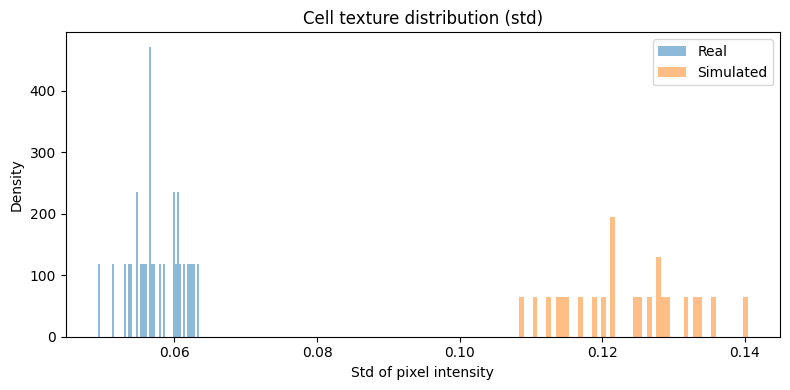

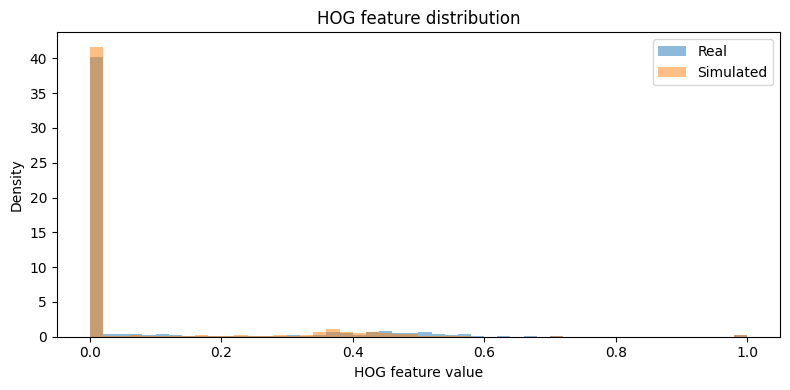

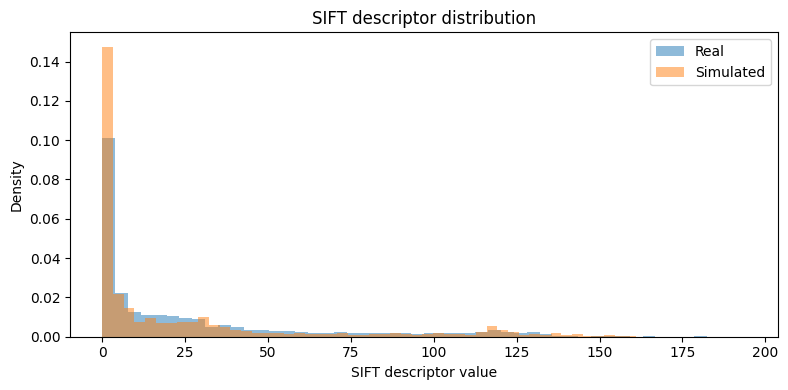

In [1]:
import subprocess
subprocess.run(["python", "-m", "pip", "install", "-e", "C:/Users/David/Desktop/sim2realgap"])
import numpy as np
import sim2realgap as s2r

# -------------------------------------------------------
# Generate synthetic data to test without real datasets
# -------------------------------------------------------

np.random.seed(42)
n_frames, H, W = 3, 128, 128

def make_synthetic_data(n_cells=10, cell_radius=8, brightness=0.7, noise=0.05):
    """Create synthetic images and masks with circular cells."""
    images = np.zeros((n_frames, H, W), dtype=np.float32)
    masks  = np.zeros((n_frames, H, W), dtype=np.float32)

    for f in range(n_frames):
        for cell_id in range(1, n_cells + 1):
            cx = np.random.randint(cell_radius, H - cell_radius)
            cy = np.random.randint(cell_radius, W - cell_radius)
            for i in range(H):
                for j in range(W):
                    if (i - cx)**2 + (j - cy)**2 < cell_radius**2:
                        images[f, i, j] = brightness + np.random.randn() * noise
                        masks[f,  i, j] = cell_id / n_cells  # unique float per cell

        images[f] = np.clip(images[f], 0, 1)

    return images, masks


print("Generating synthetic data for testing...")
real_images, real_masks = make_synthetic_data(n_cells=10, brightness=0.7, noise=0.05)
sim_images,  sim_masks  = make_synthetic_data(n_cells=8,  brightness=0.5, noise=0.1)

frames = [0, 1, 2]

# -------------------------------------------------------
# Test 1: analyze_mask
# -------------------------------------------------------
print("\n--- Test 1: analyze_mask ---")
n_cells, areas, intensities, locs = s2r.analyze_mask(real_masks[0], real_images[0])
print(f"Detected cells: {n_cells}")
print(f"Areas:          {[round(a, 4) for a in areas[:3]]}")
print(f"Intensities:    {[round(i, 4) for i in intensities[:3]]}")

# -------------------------------------------------------
# Test 2: collect_features
# -------------------------------------------------------
print("\n--- Test 2: collect_features ---")
areas_real, intensities_real = s2r.collect_features(real_images, real_masks, frames)
areas_sim,  intensities_sim  = s2r.collect_features(sim_images,  sim_masks,  frames)
print(f"Real  — n={len(areas_real)}, mean area={areas_real.mean():.4f}")
print(f"Sim   — n={len(areas_sim)},  mean area={areas_sim.mean():.4f}")

# -------------------------------------------------------
# Test 3: collect_pixels
# -------------------------------------------------------
print("\n--- Test 3: collect_pixels ---")
pixels_real = s2r.collect_pixels(real_images, real_masks, frames)
pixels_sim  = s2r.collect_pixels(sim_images,  sim_masks,  frames)
print(f"Real pixels — n={len(pixels_real)}, mean={pixels_real.mean():.4f}")
print(f"Sim  pixels — n={len(pixels_sim)},  mean={pixels_sim.mean():.4f}")

# -------------------------------------------------------
# Test 4: collect_cell_std
# -------------------------------------------------------
print("\n--- Test 4: collect_cell_std ---")
std_real = s2r.collect_cell_std(real_images, real_masks, frames)
std_sim  = s2r.collect_cell_std(sim_images,  sim_masks,  frames)
print(f"Real std — mean={std_real.mean():.4f}")
print(f"Sim  std — mean={std_sim.mean():.4f}")

# -------------------------------------------------------
# Test 5: GMM and KL divergence (2D)
# -------------------------------------------------------
print("\n--- Test 5: fit_gmm + kl_gmm ---")
gmm_real = s2r.fit_gmm(areas_real, intensities_real)
gmm_sim  = s2r.fit_gmm(areas_sim,  intensities_sim)
kl = s2r.kl_gmm(gmm_real, gmm_sim)
print(f"KL(real || sim) = {kl:.2f}")

# -------------------------------------------------------
# Test 6: GMM and KL divergence (1D)
# -------------------------------------------------------
print("\n--- Test 6: fit_gmm_1d + kl_gmm_1d ---")
gmm_area_real = s2r.fit_gmm_1d(areas_real)
gmm_area_sim  = s2r.fit_gmm_1d(areas_sim)
kl_area = s2r.kl_gmm_1d(gmm_area_real, gmm_area_sim)
print(f"KL area (real || sim) = {kl_area:.2f}")

gmm_int_real = s2r.fit_gmm_1d(intensities_real)
gmm_int_sim  = s2r.fit_gmm_1d(intensities_sim)
kl_int = s2r.kl_gmm_1d(gmm_int_real, gmm_int_sim)
print(f"KL intensity (real || sim) = {kl_int:.2f}")

# -------------------------------------------------------
# Test 7: HOG features
# -------------------------------------------------------
print("\n--- Test 7: collect_hog_features ---")
hog_real = s2r.collect_hog_features(real_images, frames)
hog_sim  = s2r.collect_hog_features(sim_images,  frames)
print(f"Real HOG — shape={hog_real.shape}, mean={hog_real.mean():.4f}")
print(f"Sim  HOG — shape={hog_sim.shape},  mean={hog_sim.mean():.4f}")

# -------------------------------------------------------
# Test 8: SIFT descriptors
# -------------------------------------------------------
print("\n--- Test 8: collect_sift_descriptors ---")
sift_real = s2r.collect_sift_descriptors(real_images, frames)
sift_sim  = s2r.collect_sift_descriptors(sim_images,  frames)
print(f"Real SIFT — n={len(sift_real)}, mean={sift_real.mean():.4f}")
print(f"Sim  SIFT — n={len(sift_sim)},  mean={sift_sim.mean():.4f}")


# -------------------------------------------------------
# Test 9: SIFT visualize
# -------------------------------------------------------
print("\n--- Test 9: visualize_sift_keypoints ---")
# 2 datasets compared
s2r.visualize_sift_keypoints(
    {
        "Real":     real_images[0],
        "Simulated": sim_images[0],
    },
    title="SIFT Keypoints — Real vs Sim"
)

# Multiple datasets
s2r.visualize_sift_keypoints(
    {
        "Real":     real_images[0],
        "Default":  sim_images[0],
        "Inferred": sim_images[1],
    },
    title="SIFT Keypoints — Real vs Default vs Inferred"
)
# -------------------------------------------------------
# Test 10: Plots
# -------------------------------------------------------
print("\n--- Test 10: plots ---")

# KL matrix
names = ["Real", "Sim"]
KL = np.array([[0.0, kl], [s2r.kl_gmm(gmm_sim, gmm_real), 0.0]])
s2r.plot_kl_matrix(KL, names, title="KL Divergence")

# Cell areas
s2r.plot_histograms(
    {"Real": areas_real, "Simulated": areas_sim},
    title="Cell area distribution",
    xlabel="Area"
)

# Cell intensities
s2r.plot_histograms(
    {"Real": intensities_real, "Simulated": intensities_sim},
    title="Cell intensity distribution",
    xlabel="Mean intensity"
)

# Cell pixels (masked)
s2r.plot_histograms(
    {"Real": pixels_real, "Simulated": pixels_sim},
    title="Cell pixel distribution",
    xlabel="Pixel intensity"
)

# Full image pixels (no masking)
full_pixels_real = s2r.collect_full_pixels(real_images, frames)
full_pixels_sim  = s2r.collect_full_pixels(sim_images,  frames)
s2r.plot_histograms(
    {"Real": full_pixels_real, "Simulated": full_pixels_sim},
    title="Full image pixel distribution",
    xlabel="Pixel intensity"
)

# Cell texture (std)
s2r.plot_histograms(
    {"Real": std_real, "Simulated": std_sim},
    title="Cell texture distribution (std)",
    xlabel="Std of pixel intensity"
)

# HOG features
s2r.plot_histograms(
    {"Real": hog_real, "Simulated": hog_sim},
    title="HOG feature distribution",
    xlabel="HOG feature value"
)

# SIFT descriptors
sift_real = s2r.collect_sift_descriptors(real_images, frames)
sift_sim  = s2r.collect_sift_descriptors(sim_images,  frames)
s2r.plot_histograms(
    {"Real": sift_real, "Simulated": sift_sim},
    title="SIFT descriptor distribution",
    xlabel="SIFT descriptor value"
)